## dataco-smart-supply-chain for Delay Delivery

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings('ignore')

In [2]:
df = pd.read_csv(r"D:\All Project DS\Supply_chain_data\dataco-smart-supply-chain\DataCoSupplyChainDataset.csv", encoding="latin1")
df.head()


,Type,Days for shipping (real),Days for shipment (scheduled),Benefit per order,Sales per customer,Delivery Status,Late_delivery_risk,Category Id,Category Name,Customer City,...,Order Zipcode,Product Card Id,Product Category Id,Product Description,Product Image,Product Name,Product Price,Product Status,shipping date (DateOrders),Shipping Mode
0,DEBIT,3,4,91.250000,314.640015,Advance shipping,0,73,Sporting Goods,Caguas,...,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,2/3/2018 22:56,Standard Class
1,TRANSFER,5,4,-249.089996,311.359985,Late delivery,1,73,Sporting Goods,Caguas,...,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,1/18/2018 12:27,Standard Class
2,CASH,4,4,-247.779999,309.720001,Shipping on time,0,73,Sporting Goods,San Jose,...,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,1/17/2018 12:06,Standard Class
3,DEBIT,3,4,22.860001,304.809998,Advance shipping,0,73,Sporting Goods,Los Angeles,...,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,1/16/2018 11:45,Standard Class
4,PAYMENT,2,4,134.210007,298.250000,Advance shipping,0,73,Sporting Goods,Caguas,...,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,1/15/2018 11:24,Standard Class


In [3]:
df.shape

(180519, 53)

In [4]:
df.columns.tolist()

['Type',
 'Days for shipping (real)',
 'Days for shipment (scheduled)',
 'Benefit per order',
 'Sales per customer',
 'Delivery Status',
 'Late_delivery_risk',
 'Category Id',
 'Category Name',
 'Customer City',
 'Customer Country',
 'Customer Email',
 'Customer Fname',
 'Customer Id',
 'Customer Lname',
 'Customer Password',
 'Customer Segment',
 'Customer State',
 'Customer Street',
 'Customer Zipcode',
 'Department Id',
 'Department Name',
 'Latitude',
 'Longitude',
 'Market',
 'Order City',
 'Order Country',
 'Order Customer Id',
 'order date (DateOrders)',
 'Order Id',
 'Order Item Cardprod Id',
 'Order Item Discount',
 'Order Item Discount Rate',
 'Order Item Id',
 'Order Item Product Price',
 'Order Item Profit Ratio',
 'Order Item Quantity',
 'Sales',
 'Order Item Total',
 'Order Profit Per Order',
 'Order Region',
 'Order State',
 'Order Status',
 'Order Zipcode',
 'Product Card Id',
 'Product Category Id',
 'Product Description',
 'Product Image',
 'Product Name',
 'Product P

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 180519 entries, 0 to 180518
Data columns (total 53 columns):
 #   Column                         Non-Null Count   Dtype  
---  ------                         --------------   -----  
 0   Type                           180519 non-null  object 
 1   Days for shipping (real)       180519 non-null  int64  
 2   Days for shipment (scheduled)  180519 non-null  int64  
 3   Benefit per order              180519 non-null  float64
 4   Sales per customer             180519 non-null  float64
 5   Delivery Status                180519 non-null  object 
 6   Late_delivery_risk             180519 non-null  int64  
 7   Category Id                    180519 non-null  int64  
 8   Category Name                  180519 non-null  object 
 9   Customer City                  180519 non-null  object 
 10  Customer Country               180519 non-null  object 
 11  Customer Email                 180519 non-null  object 
 12  Customer Fname                

#### Understand the Dataset

In [6]:
df.describe()

,Days for shipping (real),Days for shipment (scheduled),Benefit per order,Sales per customer,Late_delivery_risk,Category Id,Customer Id,Customer Zipcode,Department Id,Latitude,...,Order Item Quantity,Sales,Order Item Total,Order Profit Per Order,Order Zipcode,Product Card Id,Product Category Id,Product Description,Product Price,Product Status
count,180519.000000,180519.000000,180519.000000,180519.000000,180519.000000,180519.000000,180519.000000,180516.000000,180519.000000,180519.000000,...,180519.000000,180519.000000,180519.000000,180519.000000,24840.000000,180519.000000,180519.000000,0.0,180519.000000,180519.0
mean,3.497654,2.931847,21.974989,183.107609,0.548291,31.851451,6691.379495,35921.126914,5.443460,29.719955,...,2.127638,203.772096,183.107609,21.974989,55426.132327,692.509764,31.851451,NaN,141.232550,0.0
std,1.623722,1.374449,104.433526,120.043670,0.497664,15.640064,4162.918106,37542.461122,1.629246,9.813646,...,1.453451,132.273077,120.043670,104.433526,31919.279101,336.446807,15.640064,NaN,139.732492,0.0
min,0.000000,0.000000,-4274.979980,7.490000,0.000000,2.000000,1.000000,603.000000,2.000000,-33.937553,...,1.000000,9.990000,7.490000,-4274.979980,1040.000000,19.000000,2.000000,NaN,9.990000,0.0
25%,2.000000,2.000000,7.000000,104.379997,0.000000,18.000000,3258.500000,725.000000,4.000000,18.265432,...,1.000000,119.980003,104.379997,7.000000,23464.000000,403.000000,18.000000,NaN,50.000000,0.0
50%,3.000000,4.000000,31.520000,163.990005,1.000000,29.000000,6457.000000,19380.000000,5.000000,33.144863,...,1.000000,199.919998,163.990005,31.520000,59405.000000,627.000000,29.000000,NaN,59.990002,0.0
75%,5.000000,4.000000,64.800003,247.399994,1.000000,45.000000,9779.000000,78207.000000,7.000000,39.279617,...,3.000000,299.950012,247.399994,64.800003,90008.000000,1004.000000,45.000000,NaN,199.990005,0.0
max,6.000000,4.000000,911.799988,1939.989990,1.000000,76.000000,20757.000000,99205.000000,12.000000,48.781933,...,5.000000,1999.989990,1939.989990,911.799988,99301.000000,1363.000000,76.000000,NaN,1999.989990,0.0


In [7]:
df.isnull().sum()

Type                                  0
Days for shipping (real)              0
Days for shipment (scheduled)         0
Benefit per order                     0
Sales per customer                    0
Delivery Status                       0
Late_delivery_risk                    0
Category Id                           0
Category Name                         0
Customer City                         0
Customer Country                      0
Customer Email                        0
Customer Fname                        0
Customer Id                           0
Customer Lname                        8
Customer Password                     0
Customer Segment                      0
Customer State                        0
Customer Street                       0
Customer Zipcode                      3
Department Id                         0
Department Name                       0
Latitude                              0
Longitude                             0
Market                                0


##### Only Show Missing Values Columns

In [8]:
missing = df.isnull().sum()

missing[missing > 0]

Customer Lname              8
Customer Zipcode            3
Order Zipcode          155679
Product Description    180519
dtype: int64

In [9]:
df.duplicated().sum()

np.int64(0)

#### Remove Unnecessary Columns

In [10]:
drop_colums = [

    # Leak Data
    "Delivery Status", 
    "Days for shipping (real)", 

    # Personal Information
    "Customer Email",
    "Customer Fname ",
     "Customer Lname",
    "Customer Password",
     "Customer Street",
    
    #Image 
    "Product Description",
    "Product Image",

    # IDs
    "Customer Id",
    "Order Customer Id",
    "Order Id",
    "Order Item Id",
    "Product Card Id",

     # Location details not needed for beginner ML
    "Latitude",
    "Longitude",
    "Order Zipcode",
    "Customer Zipcode"

]

In [11]:
df.drop(columns=drop_colums, inplace=True, errors="ignore")

In [12]:
df.shape

(180519, 36)

#### Convert Date Columns

In [13]:
[col for col in df.columns if "date" in col.lower()]

['order date (DateOrders)', 'shipping date (DateOrders)']

In [14]:
df["order date (DateOrders)"] = pd.to_datetime(df["order date (DateOrders)"], errors="coerce")
df["shipping date (DateOrders)"] = pd.to_datetime(df["shipping date (DateOrders)"], errors="coerce")

In [15]:
df[["order date (DateOrders)", "shipping date (DateOrders)"]].head()

,order date (DateOrders),shipping date (DateOrders)
0,2018-01-31 22:56:00,2018-02-03 22:56:00
1,2018-01-13 12:27:00,2018-01-18 12:27:00
2,2018-01-13 12:06:00,2018-01-17 12:06:00
3,2018-01-13 11:45:00,2018-01-16 11:45:00
4,2018-01-13 11:24:00,2018-01-15 11:24:00


####  Feature Engineering 

##### Create New Columns For Year, Minths, Date

In [16]:

df["Order_Year"] = df["order date (DateOrders)"].dt.year # Order Year
df["Order_Month"] = df["order date (DateOrders)"].dt.month  #Order Month
df["Order_Day"] = df["order date (DateOrders)"].dt.day      # Order Day
df["Order_Weekday"] = df["order date (DateOrders)"].dt.dayofweek    # Order Week

In [17]:
df[["Order_Year", "Order_Month", "Order_Day", "Order_Weekday"]].head()

,Order_Year,Order_Month,Order_Day,Order_Weekday
0,2018,1,31,2
1,2018,1,13,5
2,2018,1,13,5
3,2018,1,13,5
4,2018,1,13,5


#### Profit Margin 

In [18]:
df["Profit_Margin_Percentage"] = (df["Order Profit Per Order"] / df["Sales"]) * 100

#### Replace The 
#### np.inf → Positive infinity ∞
#### -np.inf → Negative infinity -∞
#### np.nan → Missing/empty value

In [19]:
df["Profit_Margin_Percentage"] = df["Profit_Margin_Percentage"].replace([np.inf, -np.inf], np.nan)
df["Profit_Margin_Percentage"] = df["Profit_Margin_Percentage"].fillna(0)  ##### Fill Missing Values

## Everything Is Done After EDA Parts Doing 

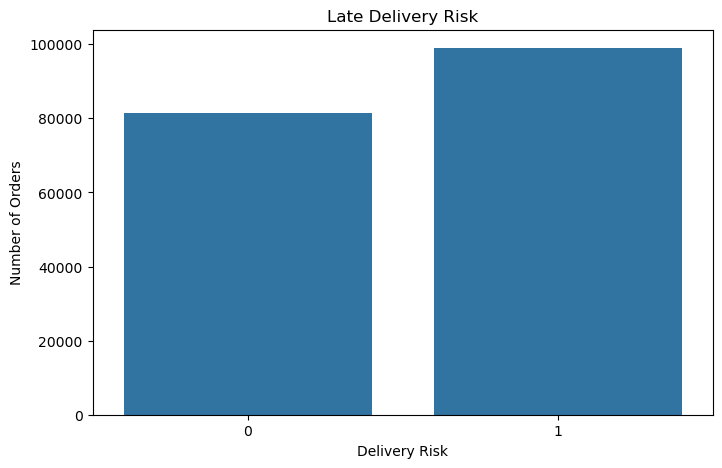

In [20]:
plt.figure(figsize=(8, 5))

ax = sns.countplot(df, x="Late_delivery_risk",)

plt.title("Late Delivery Risk")
plt.xlabel("Delivery Risk")
plt.ylabel("Number of Orders")
plt.show()

# 0 → Not Late
# 1 → Late

In [21]:
late_percentage = df["Late_delivery_risk"].value_counts(
    normalize=True
) * 100  #  100  Using For Percentage

print(late_percentage)

Late_delivery_risk
1    54.829132
0    45.170868
Name: proportion, dtype: float64


In [22]:
shipping_risk = df.groupby(
    "Shipping Mode"
)["Late_delivery_risk"].mean() *100

shipping_risk = shipping_risk.sort_values(
    ascending=False
)

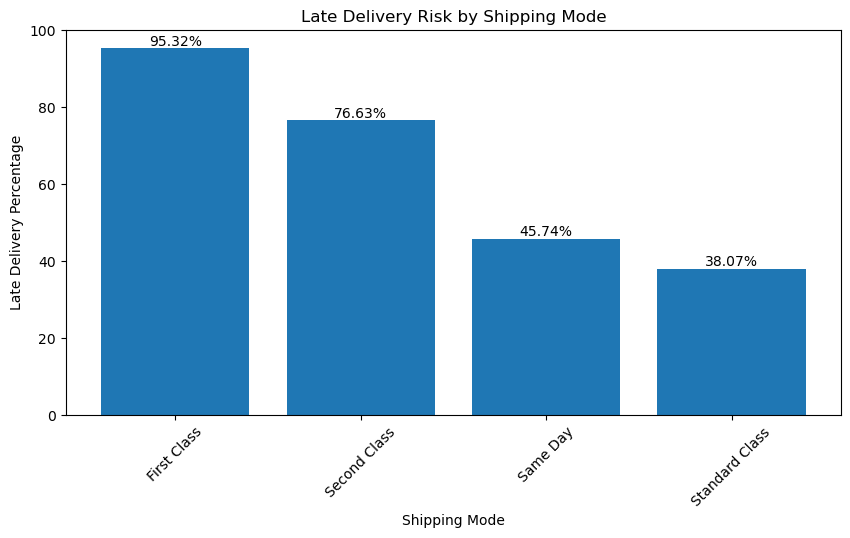

In [23]:
plt.figure(figsize=(10, 5))

bars = plt.bar(
    shipping_risk.index,
    shipping_risk.values
)

plt.bar_label(
    bars,
    fmt="%.2f%%"
)

plt.xlabel("Shipping Mode")

plt.ylabel("Late Delivery Percentage")

plt.title("Late Delivery Risk by Shipping Mode")

plt.xticks(rotation=45)

plt.show()

### Which shipping method has the highest risk of late delivery?
### First Class method has the highest risk of late delivery?

##

### Late Delivery by Market

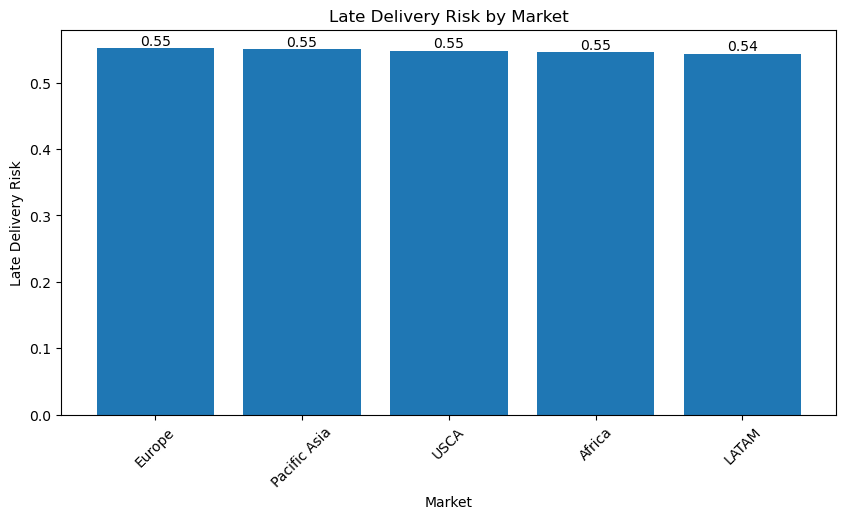

In [24]:
#  Calculate late delivery risk by market 
market_risk = ( df.groupby("Market")["Late_delivery_risk"] .mean().
               sort_values(ascending=False) )
# Create bar chart
plt.figure(figsize=(10, 5))
bars = plt.bar(market_risk.index, market_risk.values)
plt.bar_label(bars, fmt="%.2f")

plt.xlabel("Market") 
plt.ylabel("Late Delivery Risk") 
plt.title("Late Delivery Risk by Market") 
plt.xticks(rotation=45) 
plt.show()


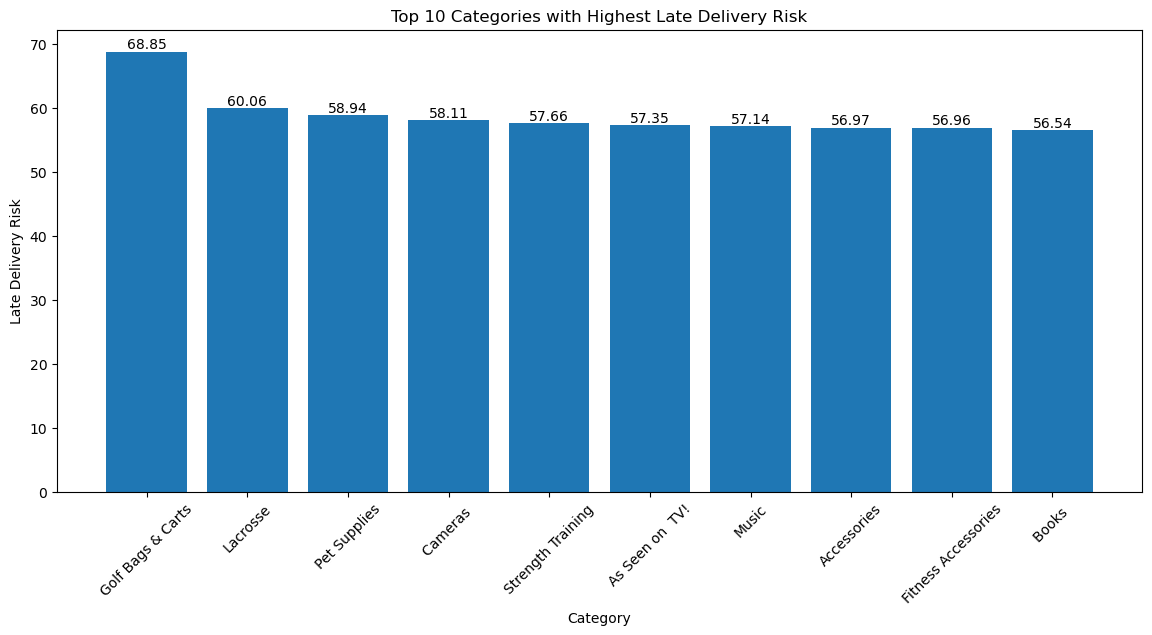

In [25]:

top10 = df.groupby('Category Name')['Late_delivery_risk'].mean().sort_values(ascending=False).head(10) *100

plt.figure(figsize=(14, 6))

bars = plt.bar(top10.index, top10.values)  # Index Contains Category Names and Values Contain Late Delivery Risk

plt.bar_label(bars, fmt="%.2f")

plt.xlabel("Category")

plt.ylabel("Late Delivery Risk")

plt.title("Top 10 Categories with Highest Late Delivery Risk")

plt.xticks(rotation=45)

plt.show()


### Total Sales By Market

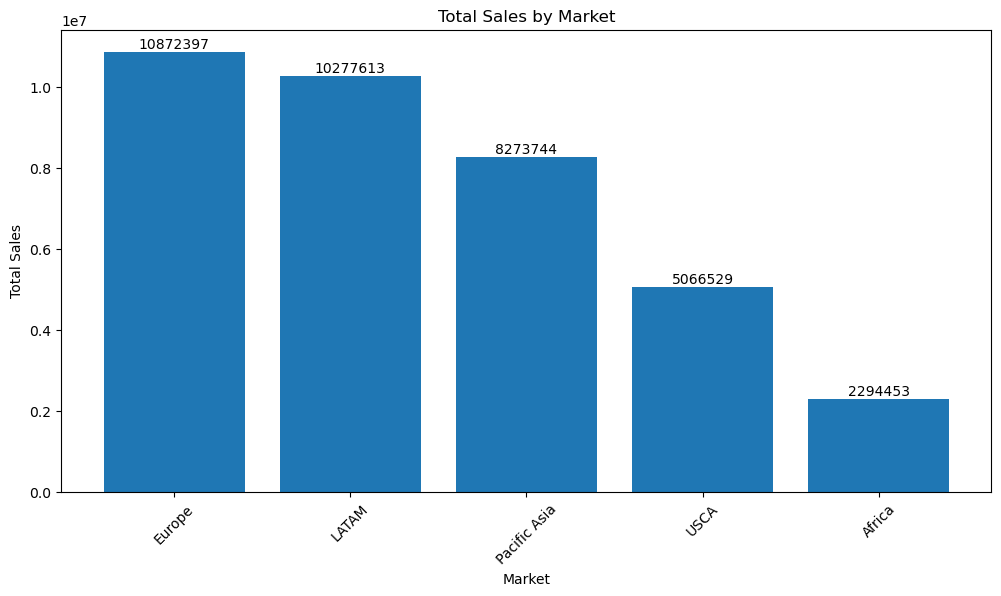

In [26]:
market_sales = df.groupby(
    "Market"
)["Sales"].sum().sort_values(
    ascending=False
)

plt.figure(figsize=(12, 6))

bars = plt.bar(
    market_sales.index,
    market_sales.values
)

plt.bar_label(
    bars,
    fmt="%.0f"
)

plt.xlabel("Market")
plt.ylabel("Total Sales")
plt.title("Total Sales by Market")
plt.xticks(rotation=45)

plt.show()

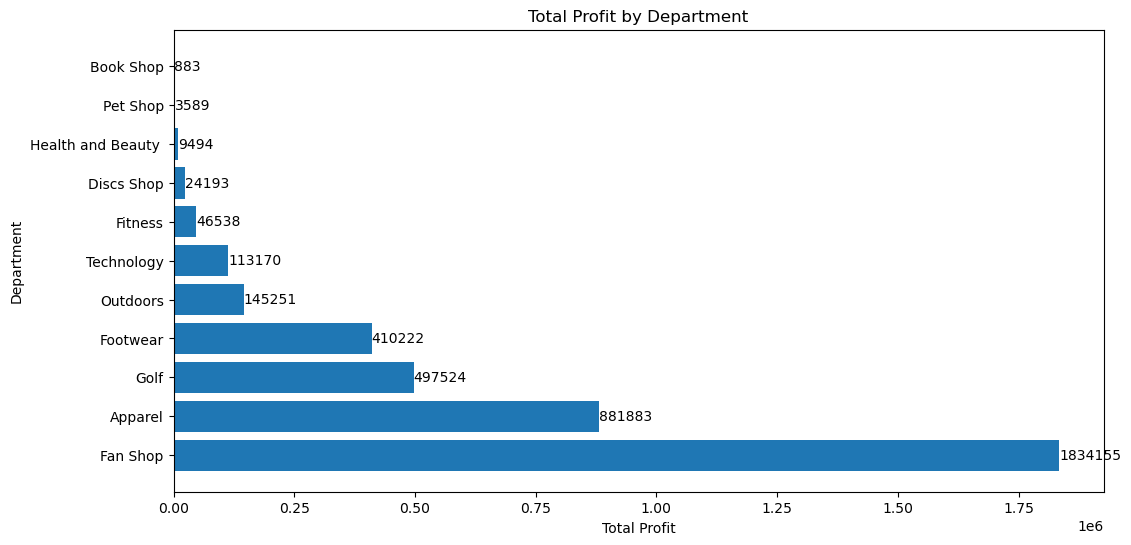

In [27]:
department_profit = df.groupby("Department Name"
    )["Order Profit Per Order"].sum().sort_values(
    ascending=False
)

plt.figure(figsize=(12, 6))

bars = plt.barh(
    department_profit.index,
    department_profit.values
)

plt.bar_label(
    bars,
    fmt="%.0f"
)

plt.xlabel("Total Profit")
plt.ylabel("Department")
plt.title("Total Profit by Department")

plt.show()

## Sales Trends By Year

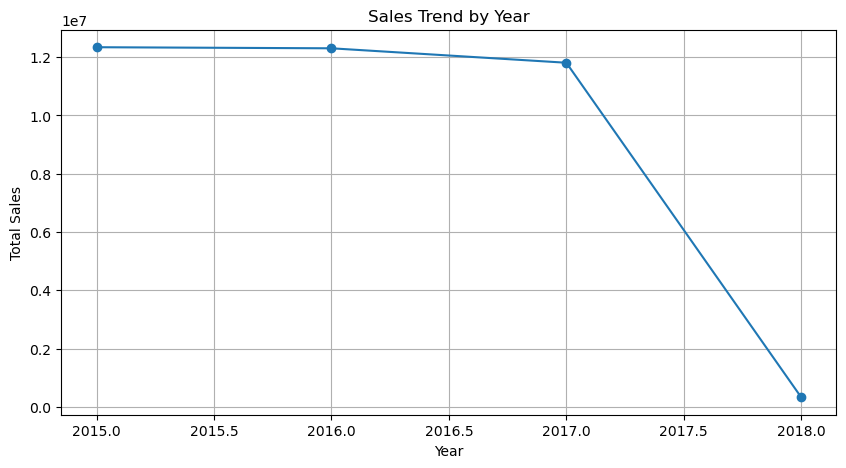

In [28]:
year_sales = df.groupby(
    "Order_Year"
)["Sales"].sum()

plt.figure(figsize=(10, 5))

plt.plot(
    year_sales.index,
    year_sales.values,
    marker="o"
)

plt.xlabel("Year")
plt.ylabel("Total Sales")
plt.title("Sales Trend by Year")
plt.grid()

plt.show()

##

#  Data for Machine Learning

In [29]:
features = [
    "Shipping Mode",
    "Customer Segment",
    "Market",
    "Order Region",
    "Category Name",
    "Department Name",
    "Order Item Quantity",
    "Sales",
    "Order Item Discount",
    "Order Item Discount Rate",
    "Product Price",
    "Order Profit Per Order",
    "Days for shipment (scheduled)",
    "Order_Year",
    "Order_Month",
    "Order_Weekday"
]


In [30]:
from scipy.stats import zscore
import numpy as np

outlier_columns = [
    "Order Item Quantity",
    "Sales",
    "Order Item Discount",
    "Order Item Discount Rate",
    "Product Price",
    "Order Profit Per Order",
    "Days for shipment (scheduled)"
]

# Calculate Z-score
z_scores = np.abs(zscore(df[outlier_columns], nan_policy="omit"))

# Remove rows where Z-score >= 3
dfn = df[(z_scores < 3).all(axis=1)].copy()

print("Original shape:", df.shape)
print("After outlier removal:", dfn.shape)

Original shape: (180519, 41)
After outlier removal: (175011, 41)


#### Label Encoder

In [31]:
from sklearn.preprocessing import LabelEncoder

x = dfn[features].copy()

for col in x.select_dtypes(include="object").columns:
    le = LabelEncoder()
    x[col] = le.fit_transform(x[col].astype(str))

y = dfn["Late_delivery_risk"]

print(x.shape)
print(x.columns.tolist())

(175011, 16)
['Shipping Mode', 'Customer Segment', 'Market', 'Order Region', 'Category Name', 'Department Name', 'Order Item Quantity', 'Sales', 'Order Item Discount', 'Order Item Discount Rate', 'Product Price', 'Order Profit Per Order', 'Days for shipment (scheduled)', 'Order_Year', 'Order_Month', 'Order_Weekday']


In [32]:
print(x.shape)
print(y.shape)

(175011, 16)
(175011,)


In [33]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

# Logistic Regression
lr_model = LogisticRegression(max_iter=1000)

# Decision Tree
dt_model = DecisionTreeClassifier(random_state=42)

# Random Forest
rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

In [34]:
from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(
    x, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

lr_model.fit(x_train, y_train)
dt_model.fit(x_train, y_train)
rf_model.fit(x_train, y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [35]:
print("X Train:", x_train.shape)

print("X Test:", x_test.shape)

print("y Train:", y_train.shape)

print("y Test:", y_test.shape)

X Train: (140008, 16)
X Test: (35003, 16)
y Train: (140008,)
y Test: (35003,)


In [36]:
print("X Train Shape:", x_train.shape)
print("X Test Shape:", x_test.shape)
print("X Train Memory:", x_train.memory_usage(deep=True).sum() / (1024**3), "GB")

X Train Shape: (140008, 16)
X Test Shape: (35003, 16)
X Train Memory: 0.016168683767318726 GB


In [37]:
lr_pred = lr_model.predict(x_test)

dt_pred = dt_model.predict(x_test)

rf_pred = rf_model.predict(x_test)

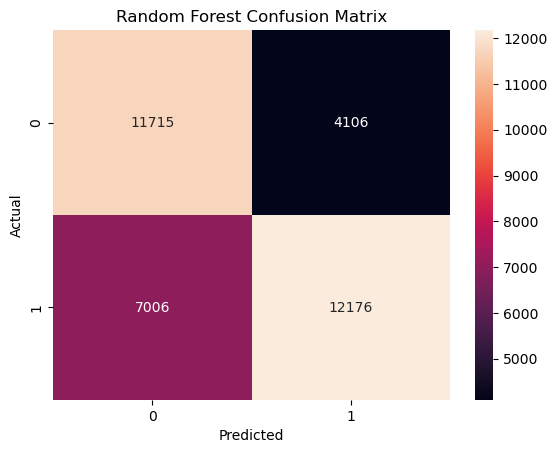

In [38]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, rf_pred)

sns.heatmap(
    cm,
    annot=True,
    fmt="d"
)

plt.title("Random Forest Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

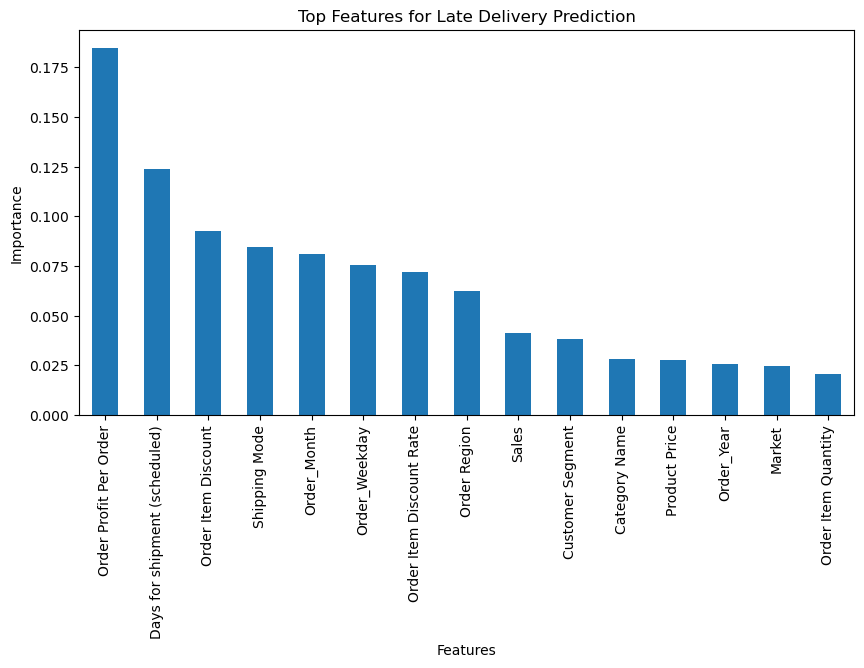

In [39]:
importance = pd.Series(
    rf_model.feature_importances_,
    index=x_train.columns
)

importance = importance.sort_values(
    ascending=False
).head(15)

importance.plot(
    kind="bar",
    figsize=(10, 5)
)

plt.title("Top Features for Late Delivery Prediction")
plt.xlabel("Features")
plt.ylabel("Importance")

plt.show()

### Saved Clean Data

In [40]:
df.to_csv(
    "cleaned_supply_chain.csv",
    index=False
)

In [41]:
import joblib

In [42]:
import joblib

joblib.dump(rf_model, "supply_chain_model.pkl")

['supply_chain_model.pkl']

In [43]:
model = joblib.load(
    "supply_chain_model.pkl"
)

In [44]:
model = joblib.load(
    "supply_chain_model.pkl"
)

## check How Many Days Your Order Is Late

In [45]:
x.tail()

,Shipping Mode,Customer Segment,Market,Order Region,Category Name,Department Name,Order Item Quantity,Sales,Order Item Discount,Order Item Discount Rate,Product Price,Order Profit Per Order,Days for shipment (scheduled),Order_Year,Order_Month,Order_Weekday
180512,3,2,3,7,17,3,1,399.980011,80.0,0.20,399.980011,86.400002,4,2016,1,5
180514,3,2,3,7,17,3,1,399.980011,0.0,0.00,399.980011,40.000000,4,2016,1,5
180516,3,1,3,11,17,3,1,399.980011,8.0,0.02,399.980011,141.110001,4,2016,1,4
180517,3,0,3,11,17,3,1,399.980011,12.0,0.03,399.980011,186.229996,4,2016,1,4
180518,3,0,3,13,17,3,1,399.980011,16.0,0.04,399.980011,168.949997,4,2016,1,4


In [46]:
a = np.array([3,	0,	3,	13,	17,	3,	1,	399.980011,	16.0,	0.04,	399.980011,	168.949997,	4,	2016,	1,	5])
a = a.reshape(1,-1)
pred = model.predict(a)

In [47]:
pred

array([0])

In [48]:
df.to_csv(
    "supply_chain_clean.csv",
    index=False
)

In [49]:
import os

print(os.getcwd())
print(os.listdir())

d:\All Project DS\Supply_chain_data\dataco-smart-supply-chain
['cleaned_supply_chain.csv', 'dataco-smart-supply-chain.ipynb', 'DataCoSupplyChainDataset.csv', 'supply_chain_clean.csv', 'supply_chain_model.pkl', 'Supply_main.sql']


In [51]:
df.head()

,Type,Days for shipment (scheduled),Benefit per order,Sales per customer,Late_delivery_risk,Category Id,Category Name,Customer City,Customer Country,Customer Fname,...,Product Name,Product Price,Product Status,shipping date (DateOrders),Shipping Mode,Order_Year,Order_Month,Order_Day,Order_Weekday,Profit_Margin_Percentage
0,DEBIT,4,91.250000,314.640015,0,73,Sporting Goods,Caguas,Puerto Rico,Cally,...,Smart watch,327.75,0,2018-02-03 22:56:00,Standard Class,2018,1,31,2,27.841342
1,TRANSFER,4,-249.089996,311.359985,1,73,Sporting Goods,Caguas,Puerto Rico,Irene,...,Smart watch,327.75,0,2018-01-18 12:27:00,Standard Class,2018,1,13,5,-75.999999
2,CASH,4,-247.779999,309.720001,0,73,Sporting Goods,San Jose,EE. UU.,Gillian,...,Smart watch,327.75,0,2018-01-17 12:06:00,Standard Class,2018,1,13,5,-75.600305
3,DEBIT,4,22.860001,304.809998,0,73,Sporting Goods,Los Angeles,EE. UU.,Tana,...,Smart watch,327.75,0,2018-01-16 11:45:00,Standard Class,2018,1,13,5,6.974829
4,PAYMENT,4,134.210007,298.250000,0,73,Sporting Goods,Caguas,Puerto Rico,Orli,...,Smart watch,327.75,0,2018-01-15 11:24:00,Standard Class,2018,1,13,5,40.948896


In [3]:
%pip install mysql-connector-python

   ---------------------------------------- 0.0/17.7 MB ? eta -:--:--
   ---------------------------------------- 0.0/17.7 MB ? eta -:--:--
   ---------------------------------------- 0.0/17.7 MB ? eta -:--:--
    --------------------------------------- 0.3/17.7 MB ? eta -:--:--
    --------------------------------------- 0.3/17.7 MB ? eta -:--:--
   - -------------------------------------- 0.5/17.7 MB 706.1 kB/s eta 0:00:25
   - -------------------------------------- 0.8/17.7 MB 757.8 kB/s eta 0:00:23
   - -------------------------------------- 0.8/17.7 MB 757.8 kB/s eta 0:00:23
   -- ------------------------------------- 1.0/17.7 MB 741.3 kB/s eta 0:00:23
   -- ------------------------------------- 1.0/17.7 MB 741.3 kB/s eta 0:00:23
   -- ------------------------------------- 1.3/17.7 MB 734.5 kB/s eta 0:00:23
   --- ------------------------------------ 1.6/17.7 MB 754.7 kB/s eta 0:00:22
   --- ------------------------------------ 1.6/17.7 MB 754.7 kB/s eta 0:00:22
   ---- ----------

In [8]:
import pandas as pd
import mysql.connector

# ==============================
# MYSQL CONNECTION
# ==============================

conn = mysql.connector.connect(
    host="localhost",
    user="root",
    password="pal@5652",
    database="supply_chain"
)

cursor = conn.cursor()

# ==============================
# FILE PATH
# ==============================

file_path = r"D:\All Project DS\Supply_chain_data\dataco-smart-supply-chain\supply_chain_clean.csv"

chunksize = 5000
total_rows = 0

# ==============================
# INSERT QUERY
# ==============================

insert_query = """
INSERT INTO orders (
    type,
    days_for_shipment_scheduled,
    benefit_per_order,
    sales_per_customer,
    late_delivery_risk,
    category_id,
    category_name,
    customer_city,
    customer_country,
    customer_fname,
    customer_segment,
    customer_state,
    department_id,
    department_name,
    market,
    order_city,
    order_country,
    order_date,
    order_item_cardprod_id,
    order_item_discount,
    order_item_discount_rate,
    order_item_product_price,
    order_item_profit_ratio,
    order_item_quantity,
    sales,
    order_item_total,
    order_profit_per_order,
    order_region,
    order_state,
    order_status,
    product_category_id,
    product_name,
    product_price,
    product_status,
    shipping_date,
    shipping_mode,
    order_year,
    order_month,
    order_day,
    order_weekday,
    profit_margin_percentage
)

VALUES (
    %s, %s, %s, %s, %s,
    %s, %s, %s, %s, %s,
    %s, %s, %s, %s, %s,
    %s, %s, %s, %s, %s,
    %s, %s, %s, %s, %s,
    %s, %s, %s, %s, %s,
    %s, %s, %s, %s, %s,
    %s, %s, %s, %s, %s,
    %s
)
"""

# ==============================
# READ CSV IN CHUNKS
# ==============================

for chunk in pd.read_csv(file_path, chunksize=chunksize):

    data = []

    for _, row in chunk.iterrows():

        values = (
            row["Type"],
            row["Days for shipment (scheduled)"],
            row["Benefit per order"],
            row["Sales per customer"],
            row["Late_delivery_risk"],
            row["Category Id"],
            row["Category Name"],
            row["Customer City"],
            row["Customer Country"],
            row["Customer Fname"],
            row["Customer Segment"],
            row["Customer State"],
            row["Department Id"],
            row["Department Name"],
            row["Market"],
            row["Order City"],
            row["Order Country"],
            row["order date (DateOrders)"],
            row["Order Item Cardprod Id"],
            row["Order Item Discount"],
            row["Order Item Discount Rate"],
            row["Order Item Product Price"],
            row["Order Item Profit Ratio"],
            row["Order Item Quantity"],
            row["Sales"],
            row["Order Item Total"],
            row["Order Profit Per Order"],
            row["Order Region"],
            row["Order State"],
            row["Order Status"],
            row["Product Category Id"],
            row["Product Name"],
            row["Product Price"],
            row["Product Status"],
            row["shipping date (DateOrders)"],
            row["Shipping Mode"],
            row["Order_Year"],
            row["Order_Month"],
            row["Order_Day"],
            row["Order_Weekday"],
            row["Profit_Margin_Percentage"]
        )

        # NaN -> NULL
        values = tuple(
            None if pd.isna(value) else value
            for value in values
        )

        data.append(values)

    # Insert chunk
    cursor.executemany(insert_query, data)

    conn.commit()

    total_rows += len(data)

    print(f"{total_rows} rows inserted...")

# ==============================
# CLOSE CONNECTION
# ==============================

cursor.close()
conn.close()

print("\n✅ All Supply Chain data successfully imported into MySQL!")

5000 rows inserted...
10000 rows inserted...
15000 rows inserted...
20000 rows inserted...
25000 rows inserted...
30000 rows inserted...
35000 rows inserted...
40000 rows inserted...
45000 rows inserted...
50000 rows inserted...
55000 rows inserted...
60000 rows inserted...
65000 rows inserted...
70000 rows inserted...
75000 rows inserted...
80000 rows inserted...
85000 rows inserted...
90000 rows inserted...
95000 rows inserted...
100000 rows inserted...
105000 rows inserted...
110000 rows inserted...
115000 rows inserted...
120000 rows inserted...
125000 rows inserted...
130000 rows inserted...
135000 rows inserted...
140000 rows inserted...
145000 rows inserted...
150000 rows inserted...
155000 rows inserted...
160000 rows inserted...
165000 rows inserted...
170000 rows inserted...
175000 rows inserted...
180000 rows inserted...
180519 rows inserted...

✅ All Supply Chain data successfully imported into MySQL!
